In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [2]:
file_path = 'cardiovascular_risk_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Данные успешно загружены. Размерность: {df.shape}")
except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден.")
    print("Пожалуйста, скачайте датасет с Kaggle и укажите правильный путь к файлу.")
    # Для демонстрации создадим заглушку, но лучше прервать выполнение
    # exit()

print("\nПервые 5 строк данных:")
display(df.head())

print("\nИнформация о данных (типы, пропуски):")
df.info()

print("\nСтатистическое описание числовых признаков:")
display(df.describe().T)

print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())

categorical_cols = df.select_dtypes(include=['object']).columns
print("\nКатегориальные признаки и их уникальные значения:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Данные успешно загружены. Размерность: (5500, 17)

Первые 5 строк данных:


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium



Информация о данных (типы, пропуски):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                   

,count,mean,std,min,25%,50%,75%,max
Patient_ID,5500.0,2750.500000,1587.857571,1.0,1375.75,2750.5,4125.25,5500.0
age,5500.0,53.872000,21.196017,18.0,36.00,54.0,72.00,90.0
bmi,5500.0,28.170818,4.189877,15.0,25.20,28.4,31.10,40.9
systolic_bp,5500.0,147.248182,13.222701,108.0,138.00,147.0,156.00,192.0
diastolic_bp,5500.0,95.756727,9.451559,64.0,89.00,96.0,102.00,120.0
cholesterol_mg_dl,5500.0,239.684182,28.570177,147.0,220.00,240.0,260.00,331.0
resting_heart_rate,5500.0,74.075091,6.392166,48.0,70.00,74.0,79.00,92.0
daily_steps,5500.0,5902.929455,3041.084590,500.0,3428.00,5460.0,7772.00,16793.0
stress_level,5500.0,4.907091,2.298173,1.0,3.00,5.0,7.00,10.0
physical_activity_hours_per_week,5500.0,3.299364,2.672457,0.0,1.20,2.6,4.90,12.9



Количество пропусков в каждом столбце:
Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Категориальные признаки и их уникальные значения:
smoking_status: ['Never' 'Current' 'Former']
family_history_heart_disease: ['No' 'Yes']
risk_category: ['Medium' 'High' 'Low']


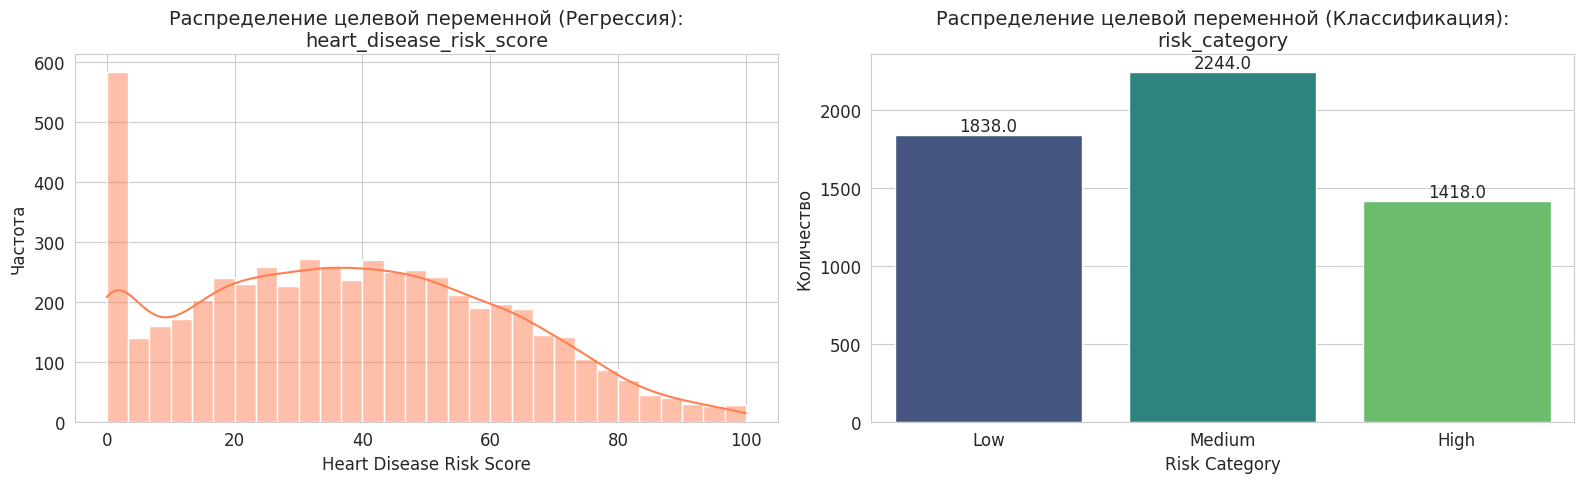

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['heart_disease_risk_score'], kde=True, bins=30, ax=axes[0], color='coral')
axes[0].set_title('Распределение целевой переменной (Регрессия):\nheart_disease_risk_score', fontsize=14)
axes[0].set_xlabel('Heart Disease Risk Score')
axes[0].set_ylabel('Частота')

order = ['Low', 'Medium', 'High']
sns.countplot(x='risk_category', data=df, order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Распределение целевой переменной (Классификация):\nrisk_category', fontsize=14)
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Количество')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

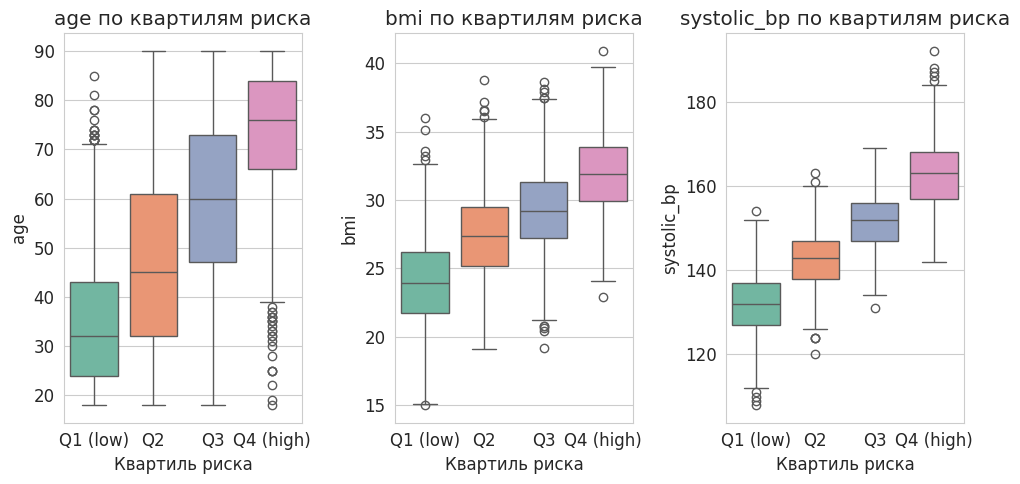

In [12]:
num_features = ['age', 'bmi', 'systolic_bp']
#'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level','physical_activity_hours_per_week', 'sleep_hours','diet_quality_score', 'alcohol_units_per_week'

df['risk_quartile'] = pd.qcut(df['heart_disease_risk_score'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.boxplot(x='risk_quartile', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} по квартилям риска')
    axes[i].set_xlabel('Квартиль риска')

plt.tight_layout()
plt.show()
df.drop('risk_quartile', axis=1, inplace=True) # Удаляем временный столбец

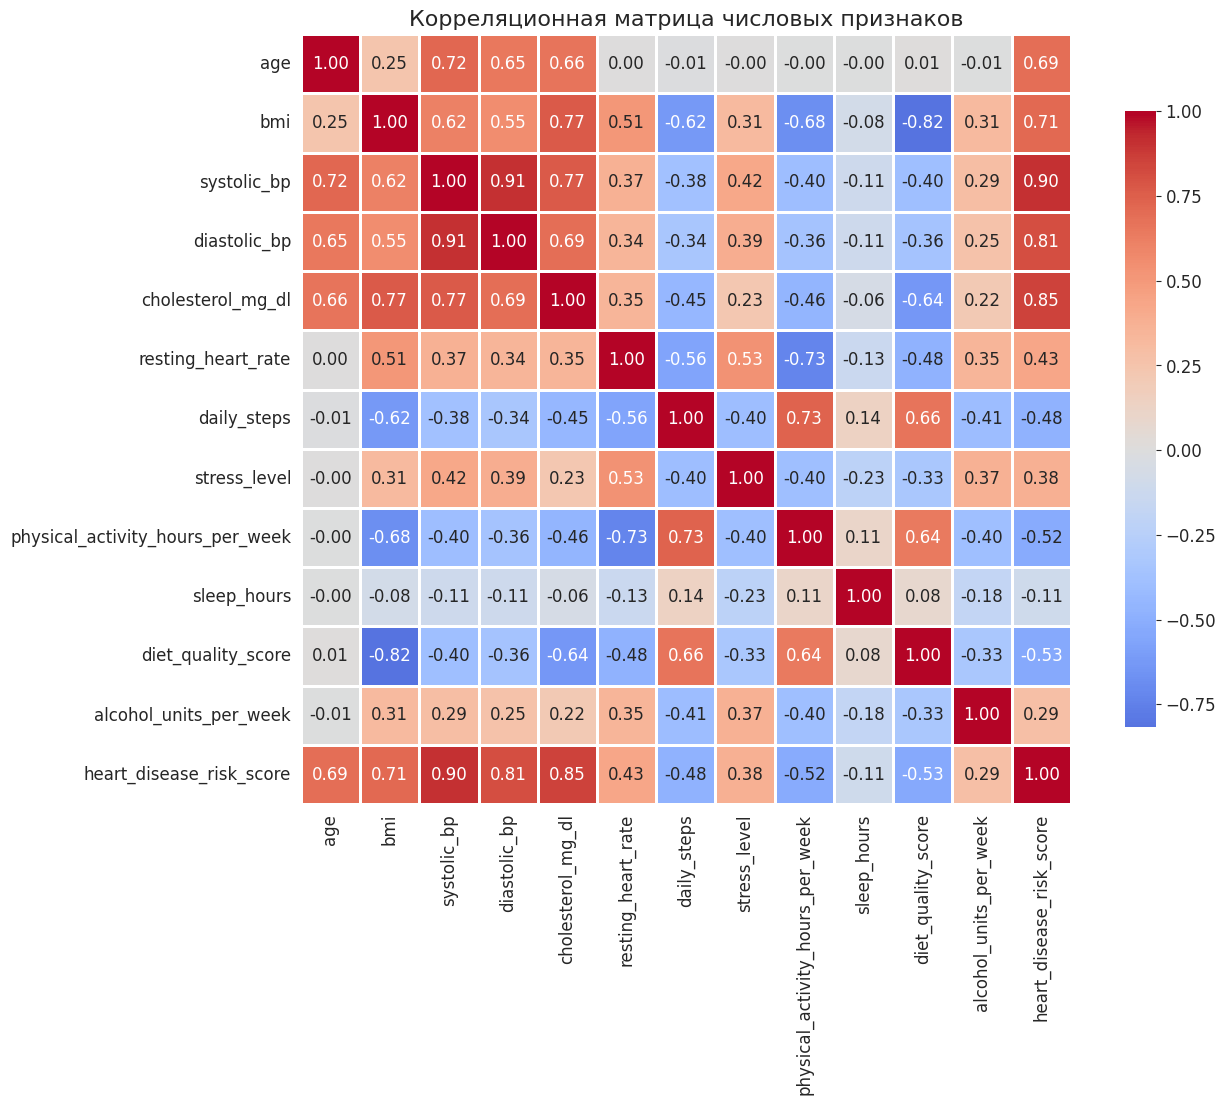

In [7]:
#Корреляционная матрица
corr_matrix = df[num_features + ['heart_disease_risk_score']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.show()

In [13]:
corr_with_target = corr_matrix['heart_disease_risk_score'].sort_values(ascending=False)
print("\nКорреляция признаков с heart_disease_risk_score:")
print(corr_with_target)


Корреляция признаков с heart_disease_risk_score:
heart_disease_risk_score            1.000000
systolic_bp                         0.901038
cholesterol_mg_dl                   0.852483
diastolic_bp                        0.813140
bmi                                 0.713077
age                                 0.694286
resting_heart_rate                  0.428760
stress_level                        0.377445
alcohol_units_per_week              0.289130
sleep_hours                        -0.105379
daily_steps                        -0.478631
physical_activity_hours_per_week   -0.520258
diet_quality_score                 -0.530838
Name: heart_disease_risk_score, dtype: float64


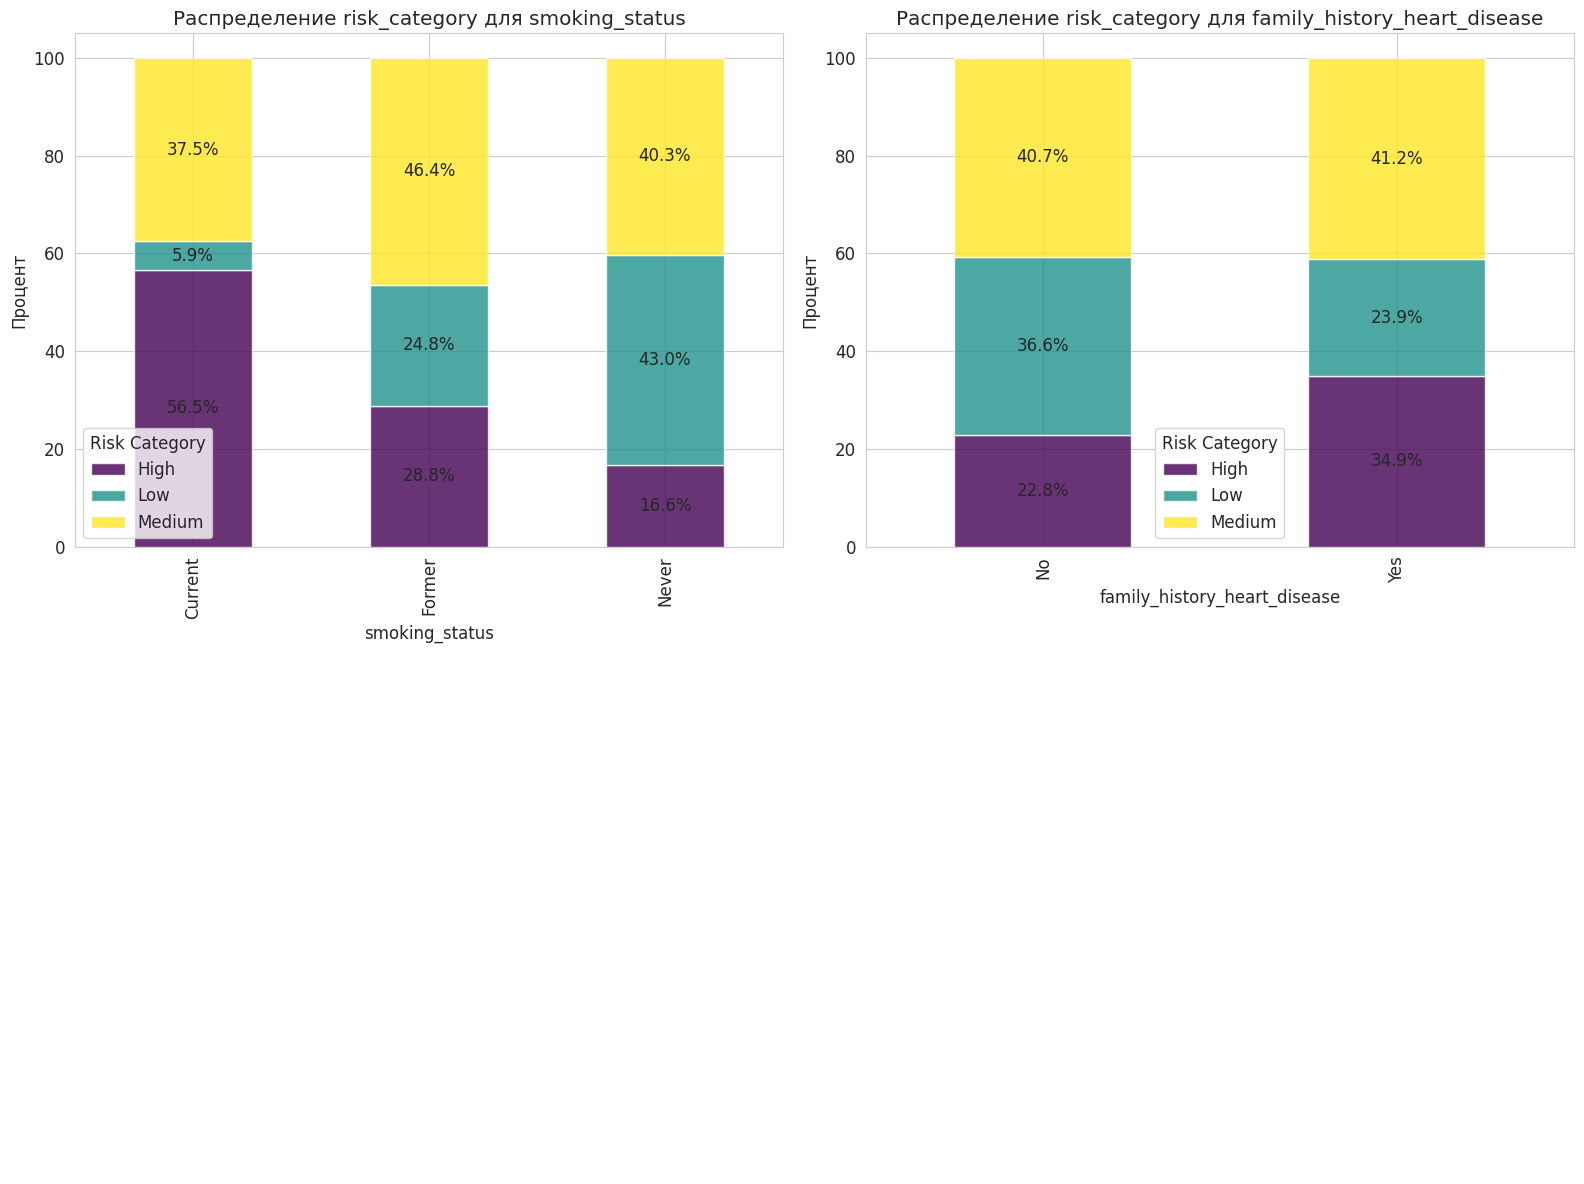

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cat_features = ['smoking_status', 'family_history_heart_disease']

for i, feature in enumerate(cat_features):
    ct = pd.crosstab(df[feature], df['risk_category'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', alpha=0.8)
    axes[i].set_title(f'Распределение risk_category для {feature}')
    axes[i].set_ylabel('Процент')
    axes[i].legend(title='Risk Category')
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', label_type='center')

for j in range(len(cat_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()